# (v5.5) Encoder-Decoder: prediction, masked prediction, generation

Difference to v5: Encoder is trained separately BERT-style to improve middle-sentence MASK prediction (bi-directional prediction) 

### The task and the model

The idea is to train a "language"-like model which could learn patterns in medical histories. For that, medical histories are presented as a flow of diagnoses with correspondent ages at which those were recorded in Electronic Health Records. Input is a csv file in long format, each row contains patient id, age, and a diagnosis. 

As before, words in this language are diagnoses, and age is used for context. 
However, we will try implementing this in two ways: 

1) age for context as in the decoder model in lifejouretys.v4
2) add age representation into the structure of the language, by making one word per year. Years with no diagnoses will be coded with a special "NO DIAGNOSIS" tokem.


**ENCODER-DECODER** models are good for next token (diagnosis) prediction, re-creating missing data in the middle and generation of similar patien stories. 

Difference from the Encoder (v4)

| Component      | Encoder-Only (BERT)                  | Encoder-Decoder (e.g., T5, BART)                |
| -------------- | ------------------------------------ | ----------------------------------------------- |
| Task           | Masked token prediction              | Sequence-to-sequence prediction                 |
| Output         | Same length as input (masked tokens) | Target sequence (e.g. future events)            |
| Attention type | Bidirectional self-attention         | Encoder: bidirectional, Decoder: causal + cross |
| Inference      | Fill-in-the-blanks                   | Generate step-by-step from initial input        |



### Approach we’ll take:

1) Preprocess DataFrame (done): Fill in years with "ND" (No Diagnosis).

2) Define a Token Vocabulary: Include [PAD], [MASK], ND, and all event tokens.

3) Create a Dataset Class: Encoder input = full sequence up to current time, Decoder input = shifted target sequence.

4) Define the model: Transformer encoder-decoder architecture.

5) Training Loop: Teacher forcing setup.

6) Inference: Autoregressive decoding for future events.

### Technical notes (COPIED from v4, need to change):

* The model learns to predict both YEAR_n and event tokens.
* years are numerical and have their own embedding. 
* the main task is for prediction of the middle of the sentence

* Tokens are organised such that [PAD] as ID 0,  [MASK] as ID 1, all unique events from df['event'] start from ID 2
* We prevent the model from predicting 'born' at any age ≠ 0, and mask out that prediction during training and inference by assigning logit = -Inf for "born" at any age>0.
*  **!!** only event loss is minimized (for event_ids), and not for Age (input_ages). Age is only used for the context. (The next version of this code _v5_ has age loss added for age prediction as well.)
 The model uses a BERT-style architecture where we predict *masked event* tokens based on context and the corresponding ages. The loss is computed using nn.CrossEntropyLoss between the model’s output logits (over vocabulary tokens) and the true token labels.

Specifically,
     loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1)).  Here, logits are the model's raw scores for each vocabulary token at each sequence position. labels: the ground truth event tokens (or -100 to ignore when not masked). Positions with label -100 are ignored due to how CrossEntropyLoss handles ignore_index=-100.


Alternative: Train Encoder Standalone - could this be better?
Yes, **training the encoder standalone with a BERT-style masked language modeling (MLM) objective can be a very effective strategy**, especially if:

---

### ✅ Why Pretrain the Encoder Alone Might Be Better

1. **Better Representation Learning**:

   * MLM helps the encoder learn deep, contextual representations of events and age positions.
   * It sees both sides of the context (bidirectional), which pure encoder-decoder training with causal decoding doesn’t allow.

2. **Data Efficiency**:

   * MLM pretraining uses more of the data, especially when you don’t have explicit labels for next-event prediction.
   * You can mask multiple parts of a sequence and get multiple training signals from a single sequence.

3. **Modular Transfer**:

   * Once pretrained, the encoder can be reused or fine-tuned for different tasks (e.g., classification, prediction, retrieval).
   * You can plug the pretrained encoder into a more complex encoder-decoder model.

4. **Simplicity**:

   * The training objective is simpler (input = output with masked tokens).
   * No decoder needed during pretraining.

---

### 🔁 Workflow

1. **Pretrain Encoder** on MLM:

   * Mask \~15% of tokens.
   * Use a linear classifier head over encoder outputs to predict masked tokens.

2. **Fine-tune Encoder-Decoder** on your event prediction task:

   * Load pretrained encoder weights.
   * Add a decoder for autoregressive generation.
   * Train to predict future events.

---

### ⚠️ When Not Better

* If your prediction task depends heavily on sequence-to-sequence dynamics (e.g., predicting exact future timelines), training the whole encoder-decoder end-to-end from scratch might be more task-aligned.
* MLM training doesn’t teach the model to **generate** sequences — it only reconstructs them.

---

### 🧠 Summary

| Strategy                         | Good For                                       | Notes                               |
| -------------------------------- | ---------------------------------------------- | ----------------------------------- |
| **Standalone Encoder (MLM)**     | Rich representations, bidirectional context    | Ideal for pretraining               |
| **Encoder-Decoder (End-to-End)** | Sequence generation, autoregressive prediction | Better for generation-focused tasks |

---

Would you like a short example of how to pretrain your encoder on MLM with your life-event data?


In [ ]:
The pretrained encoder should output hidden states of shape [batch_size, seq_len, d_model], which your decoder can consume.
Your TransformerEncoderDecoder model already does this:
memory = self.encoder(src_emb)  # shape: [B, S, d_model]

So you can replace the encoder module in that model with the pretrained BertWithAgePE.encoder.



### Start 

In [11]:
import numpy as np
import pandas as pd
import math
import random 

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn import CrossEntropyLoss
from torch.nn.utils.rnn import pad_sequence

import matplotlib.pyplot as plt


## Step 1. Train encoder as in V4.5

In [18]:
# Age Positional Encoding class
class AgePositionalEncoding(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model

    def forward(self, age_tensor):
        B, L = age_tensor.size()
        age_tensor = age_tensor.float().unsqueeze(2)

        div_term = torch.exp(
            torch.arange(0, self.d_model, 2, dtype=torch.float32, device=age_tensor.device)
            * (-math.log(10000.0) / self.d_model)
        )
        sinusoid_input = age_tensor / div_term
        pe = torch.zeros(B, L, self.d_model, device=age_tensor.device)
        pe[:, :, 0::2] = torch.sin(sinusoid_input)
        pe[:, :, 1::2] = torch.cos(sinusoid_input)
        
        # Mask out padded positions (age == -1)
        mask = (age_tensor.squeeze(2) != -1).float().unsqueeze(2)
        pe = pe * mask
        
        return pe

In [95]:
# Dataset class
class LifeEventMaskedDataset(Dataset):
    def __init__(self, df, vocab, mask_token="[MASK]", pad_token="[PAD]", mask_prob=0.15):
        self.vocab = vocab
        self.mask_token_id = vocab[mask_token]
        self.pad_token_id = vocab[pad_token]
        self.mask_prob = mask_prob
        self.samples = []

        grouped = df.groupby('patid')
        for _, group in grouped:
            group = group.sort_values('age')
            events = []
            ages = []
            for _, row in group.iterrows():
                event_token = row['event']
                if event_token in vocab:
                    events.append(vocab[event_token])
                    ages.append(int(row['age']))
            if events:
                self.samples.append((ages, events))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ages, events = self.samples[idx]
        input_events = events.copy()
        input_ages = ages.copy()
        labels = [-100] * len(events)

        for i in range(len(events)):
            if random.random() < self.mask_prob:
                labels[i] = input_events[i]
                input_events[i] = self.mask_token_id

        return {
            "input_events": torch.tensor(input_events, dtype=torch.long),
            "input_ages": torch.tensor(input_ages, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }

In [25]:
# Custom collate function for padding
def collate_fn_encoder(batch):
    EVENT_PAD_VALUE = 0  # ID for [PAD]
    AGE_PAD_VALUE = -1 # padding value for ages 
    input_events = pad_sequence([b['input_events'] for b in batch], batch_first=True, padding_value=EVENT_PAD_VALUE)
    input_ages = pad_sequence([b['input_ages'] for b in batch], batch_first=True, padding_value=AGE_PAD_VALUE)
    labels = pad_sequence([b['labels'] for b in batch], batch_first=True, padding_value=-100)
    return {"input_events": input_events, "input_ages": input_ages, "labels": labels}

In [27]:
# Encoder model
class BertWithAgePE(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, max_seq_len=256):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.age_pe = AgePositionalEncoding(d_model=d_model)
        self.pos_embedding = nn.Embedding(max_seq_len, d_model)

        # Set batch_first=True for easier handling of input shape
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_events, input_ages):
        B, L = input_events.shape
        pos = torch.arange(L, device=input_events.device).unsqueeze(0).expand(B, L)

        token_embed = self.token_embedding(input_events)
        age_embed = self.age_pe(input_ages)
        pos_embed = self.pos_embedding(pos)

        # Add token embedding, age positional encoding, and positional embedding
        x = token_embed + age_embed + pos_embed
        x = self.encoder(x)  # No need for transpose since batch_first=True
        return self.output_head(x)


In [29]:
# Training loop
def train_encoder(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in dataloader:
        input_events = batch['input_events'].to(device)
        input_ages = batch['input_ages'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_events, input_ages)
        loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)


### 2. Refactor the Encoder-Decoder Model
Modify your TransformerEncoderDecoder to **accept a pretrained encoder**:

In [33]:

class TransformerEncoderDecoder(nn.Module):
    def __init__(self, vocab_size, encoder, d_model=128, nhead=2, num_layers=2, max_seq_len=256):
        super().__init__()
        self.encoder = encoder  # Pretrained encoder passed in

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_seq_len, d_model)
        self.age_encoding = AgePositionalEncoding(d_model)

        decoder_layer = nn.TransformerDecoderLayer(d_model, nhead, batch_first=True)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers)
        self.output_head = nn.Linear(d_model, vocab_size)

    def forward(self, src, tgt, src_age, tgt_age):
        B, S = src.shape
        _, T = tgt.shape

        src_pos = torch.arange(S, device=src.device).unsqueeze(0).expand(B, S)
        tgt_pos = torch.arange(T, device=tgt.device).unsqueeze(0).expand(B, T)

        # Use pretrained encoder embeddings
        src_emb = self.encoder.token_embedding(src) + \
                  self.encoder.pos_embedding(src_pos) + \
                  self.encoder.age_pe(src_age)

        memory = self.encoder.encoder(src_emb)  # Use pretrained encoder stack

        tgt_emb = self.token_embedding(tgt) + \
                  self.pos_embedding(tgt_pos) + \
                  self.age_encoding(tgt_age)

        output = self.decoder(tgt_emb, memory)
        return self.output_head(output)


In [35]:
class EventSeqDataset(Dataset):
    def __init__(self, df, vocab, max_len=256):
        self.samples = []
        self.vocab = vocab
        pad_token = vocab['[PAD]']

        grouped = df.groupby('patid')
        for _, group in grouped:
            group = group.sort_values('age')
            tokens = [vocab[e] for e in group['event']]
            ages = list(group['age'])
            if len(tokens) > 1:
                src = tokens[:-1]
                tgt = tokens[1:]
                src_age = ages[:-1]
                tgt_age = ages[1:]

                src = src[:max_len]
                tgt = tgt[:max_len]
                src_age = src_age[:max_len]
                tgt_age = tgt_age[:max_len]

                self.samples.append((src, tgt, src_age, tgt_age))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        src, tgt, src_age, tgt_age = self.samples[idx]
        return torch.tensor(src), torch.tensor(tgt), torch.tensor(src_age), torch.tensor(tgt_age)


In [37]:
## Collate function with padding
def collate_fn(batch):
    srcs, tgts, src_ages, tgt_ages = zip(*batch)
    srcs_padded = pad_sequence(srcs, batch_first=True, padding_value=0)
    tgts_padded = pad_sequence(tgts, batch_first=True, padding_value=0)
    src_ages_padded = pad_sequence(src_ages, batch_first=True, padding_value=-1)
    tgt_ages_padded = pad_sequence(tgt_ages, batch_first=True, padding_value=-1)
    return srcs_padded, tgts_padded, src_ages_padded, tgt_ages_padded

In [39]:
def train_encoder_decoder(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for src, tgt, src_age, tgt_age in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        src_age, tgt_age = src_age.to(device), tgt_age.to(device)

        tgt_input = tgt[:, :-1]
        tgt_labels = tgt[:, 1:].contiguous().view(-1)
        tgt_input_age = tgt_age[:, :-1]

        optimizer.zero_grad()
        output = model(src, tgt_input, src_age, tgt_input_age)
        output = output.contiguous().view(-1, output.size(-1))

        loss = criterion(output, tgt_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)


In [41]:
def fill_missing_years(df, fill_event='ND'):
    filled_rows = []
    
    for patid, group in df.groupby('patid'):
        group = group.sort_values('age')
        min_age = group['age'].min()
        max_age = group['age'].max()
        
        all_ages = set(range(min_age, max_age + 1))
        recorded_ages = set(group['age'])
        missing_ages = all_ages - recorded_ages

        # Keep existing rows
        filled_rows.append(group)

        # Add ND rows for missing ages
        nd_rows = pd.DataFrame({
            'patid': patid,
            'age': list(missing_ages),
            'event': fill_event
        })
        filled_rows.append(nd_rows)

    result = pd.concat(filled_rows).sort_values(['patid', 'age']).reset_index(drop=True)
    return result

### Step 3 Implementation with the TOY DATA

In [102]:
# read training data, create main main_vocab from all events in the data, create year_main_vocab from 0 to 110
df = pd.read_csv("Event_data.csv")
df = fill_missing_years(df, "ND")
# create main_vocabulary from all diff words in df.event

unique_events = sorted(df['event'].unique())
vocab = {'[PAD]': 0, '[MASK]': 1, 'ND': 2}
for i, event in enumerate(unique_events, start=2):
    vocab[event] = i
    id_to_token = {v: k for k, v in vocab.items()}
vocab_words = [id_to_token[i] for i in id_to_token.keys()]

vocab {'[PAD]': 0,  '[MASK]': 1, 'ND': 2, 'born': 3, 'cancer': 4, 'died': 5, 'flu': 6, 't2dm': 7}

In [93]:
vocab

{'[PAD]': 0,
 '[MASK]': 1,
 'ND': 2,
 'born': 3,
 'cancer': 4,
 'died': 5,
 'flu': 6,
 't2dm': 7}

#### Step 3-1 Train encoder

In [104]:
# --- Hyperparameters ---
batch_size = 3
num_epochs = 100
lr = 1e-3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# --- Dataset creation ---
dataset_encoder = LifeEventMaskedDataset(df, vocab)
dataloader_encoder = DataLoader(dataset_encoder, batch_size=batch_size, shuffle=True, collate_fn = collate_fn_encoder)

In [89]:
df[df.patid==1]

,patid,age,event
0,1,0,born
1,1,1,ND
2,1,2,ND
3,1,3,ND
4,1,4,ND
...,...,...,...
78,1,78,ND
79,1,79,ND
80,1,80,ND
81,1,81,ND


In [108]:
dataset_encoder[0]

{'input_events': tensor([3, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2,
         2, 2, 6, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 5]),
 'input_ages': tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
         36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
         54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
         72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82]),
 'labels': tensor([-100,    2, -100,    2, -100,    2, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100,    2, -100, -100, -100, -100,    2, -100,
         -100, -100, -100,    2, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, 

In [110]:
# --- Model, Loss, Optimizer ---
model_encoder = BertWithAgePE(vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=-100)
optimizer = torch.optim.Adam(model_encoder.parameters(), lr)

In [112]:
for epoch in range(num_epochs):
    loss = train_encoder(model_encoder, dataloader_encoder, optimizer, criterion, device)
    if (epoch <= 10): 
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss:.4f}")
    else:
        if (epoch%10 == 0):
            print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss:.4f}")

Epoch 1/100 | Loss: 1.0736
Epoch 2/100 | Loss: 0.5652
Epoch 3/100 | Loss: 0.3298
Epoch 4/100 | Loss: 0.5054
Epoch 5/100 | Loss: 0.3807
Epoch 6/100 | Loss: 0.2465
Epoch 7/100 | Loss: 0.2797
Epoch 8/100 | Loss: 0.2552
Epoch 9/100 | Loss: 0.2306
Epoch 10/100 | Loss: 0.2396
Epoch 11/100 | Loss: 0.2908
Epoch 21/100 | Loss: 0.1116
Epoch 31/100 | Loss: 0.1466
Epoch 41/100 | Loss: 0.2257
Epoch 51/100 | Loss: 0.1307
Epoch 61/100 | Loss: 0.1365
Epoch 71/100 | Loss: 0.0457
Epoch 81/100 | Loss: 0.0670
Epoch 91/100 | Loss: 0.0848


#### Step 3-2 Train encoder-decoder using the pre-trained encoder

In [48]:
# --- Hyperparameters ---
batch_size = 2
num_epochs = 100
lr = 1e-3

In [114]:
# --- Dataset creation ---
dataset = EventSeqDataset(df, vocab)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn = collate_fn)

In [122]:
model = TransformerEncoderDecoder(encoder = model_encoder, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr)

In [124]:
for epoch in range(num_epochs):
    loss = train_encoder_decoder(model, dataloader, optimizer, criterion, device)
    if (epoch <= 10): 
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss:.4f}")
    else:
        if (epoch%10 == 0):
            print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss:.4f}")

Epoch 1/100 | Loss: 0.9107
Epoch 2/100 | Loss: 0.3122
Epoch 3/100 | Loss: 0.2848
Epoch 4/100 | Loss: 0.2867
Epoch 5/100 | Loss: 0.2742
Epoch 6/100 | Loss: 0.2645
Epoch 7/100 | Loss: 0.2696
Epoch 8/100 | Loss: 0.2644
Epoch 9/100 | Loss: 0.2624
Epoch 10/100 | Loss: 0.2814
Epoch 11/100 | Loss: 0.2634
Epoch 21/100 | Loss: 0.2399
Epoch 31/100 | Loss: 0.0610
Epoch 41/100 | Loss: 0.0230
Epoch 51/100 | Loss: 0.0127
Epoch 61/100 | Loss: 0.0109
Epoch 71/100 | Loss: 0.0044
Epoch 81/100 | Loss: 0.0066
Epoch 91/100 | Loss: 0.0189


tensor([7.1317e-05, 7.4178e-05, 9.9360e-01, 4.9246e-05, 6.2369e-05, 5.6944e-03,
        1.8984e-04, 2.6165e-04])


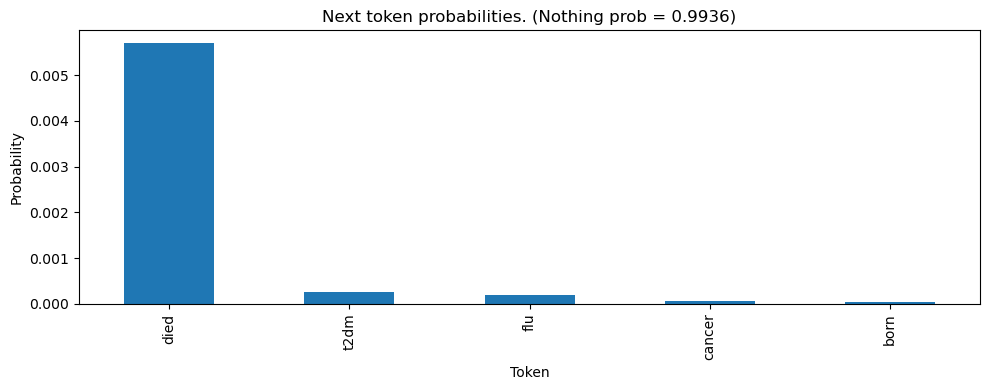

(Text(24.0, 0.5, 'Probability'), Text(0.5, 24.0, 'Token'), None, None)

In [226]:
# checking probabilities for next token 
with torch.no_grad():
    sample = next(iter(dataloader))
    out = model(*[x.to(device) for x in sample])
    print(out[0, -1].softmax(dim=0))  # Probabilities over vocab
probs = out[0,-1].softmax(dim=0).numpy()
prob_dict = {id_to_token[j]: float(probs[j]) for j in range(len(probs))}
nd_prob = round(prob_dict["ND"],4)
prob_dict.pop("[MASK]"), prob_dict.pop("[PAD]"), prob_dict.pop("ND")
pd.Series(prob_dict).sort_values(ascending=False).plot.bar(figsize=(10, 4), title=f"Next token probabilities. (Nothing prob = {nd_prob})")
plt.ylabel("Probability"), plt.xlabel("Token"), plt.tight_layout(), plt.show()


# Use cases 

## 1. Predict Future Events / Generate End of Sequence

In [381]:
def generate_future_events_with_ages(model, src, src_age, vocab, max_gen_len=10, end_token='died'):
    device = next(model.parameters()).device
    inv_vocab = {v: k for k, v in vocab.items()}
    end_token_id = vocab[end_token]

    generated_tokens = []
    generated_ages = []

    # Start from the last known event and age
    decoder_input = src[:, -1:]              # shape: [1, 1]
    decoder_age = src_age[:, -1:]            # shape: [1, 1]
    last_age = decoder_age.item()

    for _ in range(max_gen_len):
        output = model(src, decoder_input, src_age, decoder_age)
        next_token_logits = output[:, -1, :]  # Get logits for the last token
        next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)

        generated_tokens.append(next_token.item())
        last_age += 1
        generated_ages.append(last_age)

        if next_token.item() == end_token_id:
            break

        decoder_input = torch.cat([decoder_input, next_token], dim=1)
        new_age_tensor = torch.tensor([[last_age]], dtype=torch.long, device=device)
        decoder_age = torch.cat([decoder_age, new_age_tensor], dim=1)

    generated_events = [inv_vocab[token_id] for token_id in generated_tokens]
    return list(zip(generated_ages, generated_events))


In [500]:
def generate_full_timeline(df, model, vocab, patid, max_gen_len=20, end_token="died"):
    device = next(model.parameters()).device
    inv_vocab = {v: k for k, v in vocab.items()}

    # Extract and sort the patient's history
    patient_df = df[df['patid'] == patid].sort_values('age')
    known_ages = list(patient_df['age'])
    known_events = list(patient_df['event'])

    # Prepare inputs
    src_tokens = [vocab[event] for event in known_events]
    src_ages = known_ages

    src = torch.tensor([src_tokens], dtype=torch.long, device=device)
    src_age = torch.tensor([src_ages], dtype=torch.long, device=device)

    # Generate future events
    future = generate_future_events_with_ages(model, src, src_age, vocab, max_gen_len=max_gen_len, end_token=end_token)

    # Combine known and future events
    known_timeline = list(zip(known_ages, known_events))
    full_timeline = known_timeline + future

    # We also combine all into a dataframe (age, event, patid, predicted)
    # Predicted is 0 for known history and 1 for predicted 
    medjourney = pd.DataFrame(full_timeline)
    medjourney.columns = ["age", "event"]
    medjourney["patid"] = patid
    medjourney["predicted"] = [0]*len(known_timeline) + [1]*len(future)
    medjourney = medjourney[["patid", "age", "event", "predicted"]] #reorganise columns 
    
    # 3 outputs - known history, predicted history as dictionaries and altogether as a dataframe
    return known_timeline, future, medjourney


In [312]:
# to prepare medical journey for a patid for future prediction
def prepare_src_for_generation(df, vocab, patid, max_len=256):
    group = df[df['patid'] == patid].sort_values('age')
    tokens = [vocab[e] for e in group['event'] if e in vocab]
    ages = list(group['age'])

    tokens = tokens[:max_len]
    ages = ages[:max_len]

    src = torch.tensor(tokens, dtype=torch.long).unsqueeze(0)  # [1, L]
    src_age = torch.tensor(ages, dtype=torch.long).unsqueeze(0)  # [1, L]
    return src, src_age


## 2. Fill Mid-Sequence [MASK] Tokens (MLM)
This is done  with encoder (BertWithAgePE), not the full encoder-decoder.


In [315]:
def fill_masks(encoder, input_events, input_ages, vocab):
    encoder.eval()
    device = next(encoder.parameters()).device
    input_events = input_events.to(device)
    input_ages = input_ages.to(device)

    with torch.no_grad():
        logits = encoder(input_events, input_ages)

    predictions = logits.argmax(dim=-1)
    mask_id = vocab['[MASK]']
    mask_positions = (input_events == mask_id)
    input_events[mask_positions] = predictions[mask_positions]

    return input_events


In [330]:
# to prepare medical journey for a patid for mid-sentence prediction
# we tokenize patid in data frame df and then 
# brute-force MASK mask_index

def prepare_masked_input(df, vocab, patid, mask_index=1, max_len=256):
    group = df[df['patid'] == patid].sort_values('age')
    tokens = [vocab[e] for e in group['event'] if e in vocab]
    ages = list(group['age'])

    tokens = tokens[:max_len]
    ages = ages[:max_len]

    input_events = tokens.copy()
    if 0 <= mask_index < len(input_events):
        input_events[mask_index] = vocab['[MASK]']

    input_events = torch.tensor(input_events, dtype=torch.long).unsqueeze(0)
    input_ages = torch.tensor(ages, dtype=torch.long).unsqueeze(0)
    return input_events, input_ages


## Apply 1 and 2 to an example medical journey


### Apply 1 Predict Future events

In [318]:
# make up some patients 
med1 = pd.DataFrame( {"patid": [100,100, 101,101], "age": [5,20, 6, 80], "event": ["flu", "flu", "flu", "cancer"]} )
med1

,patid,age,event
0,100,5,flu
1,100,20,flu
2,101,6,flu
3,101,80,cancer


In [320]:
medlong = fill_missing_years(med1)
medlong.head()

,patid,age,event
0,100,5,flu
1,100,6,ND
2,100,7,ND
3,100,8,ND
4,100,9,ND


In [516]:
# predict for patient 100 
# 3 outputs - known history, predicted history as dictionaries and altogether as a dataframe
timeline_known, timeline_future, medjourney = generate_full_timeline(medlong, model, vocab, patid=100, max_gen_len = 100)
for age, event in timeline_known:
    if event != "ND": 
        print(f"AGE_{age} {event}")
for age, event in timeline_future:
    if event != "ND": 
        print(f"Future_AGE_{age} {event}")
medjourney[medjourney.event != "ND"]

AGE_5 flu
AGE_20 flu
Future_AGE_21 flu
Future_AGE_22 flu
Future_AGE_23 flu
Future_AGE_24 flu
Future_AGE_26 flu
Future_AGE_29 flu
Future_AGE_34 flu
Future_AGE_39 flu
Future_AGE_45 flu
Future_AGE_48 flu
Future_AGE_54 flu
Future_AGE_64 flu
Future_AGE_82 died


,patid,age,event,predicted
0,100,5,flu,0
15,100,20,flu,0
16,100,21,flu,1
17,100,22,flu,1
18,100,23,flu,1
19,100,24,flu,1
21,100,26,flu,1
24,100,29,flu,1
29,100,34,flu,1
34,100,39,flu,1


### Apply 2 Fill Mid-Sequence [MASK] Tokens (MLM)

In [347]:
med1 = pd.DataFrame( {"patid": [100,100, 101,101], "age": [5,20, 6, 80], "event": ["flu", "flu", "flu", "cancer"]} )
medlong = fill_missing_years(med1)
medlong.head()

,patid,age,event
0,100,5,flu
1,100,6,ND
2,100,7,ND
3,100,8,ND
4,100,9,ND


In [349]:
vocab

{'[PAD]': 0,
 '[MASK]': 1,
 'ND': 2,
 'born': 3,
 'cancer': 4,
 'died': 5,
 'flu': 6,
 't2dm': 7}

In [351]:
# Mask 1st position for patid = 101
input_events, input_ages = prepare_masked_input(medlong, vocab, patid=101, mask_index=1)
input_events, input_ages

(tensor([[6, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
          2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
          2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
          2, 2, 4]]),
 tensor([[ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
          24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41,
          42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59,
          60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
          78, 79, 80]]))

In [355]:
# Apply mask filling
filled = fill_masks(model_encoder, input_events, input_ages, vocab)

# Decode
inv_vocab = {v: k for k, v in vocab.items()}
filled_events = [inv_vocab[token.item()] for token in filled[0]]
print("Sequence with filled mask:", filled_events)

Sequence with filled mask: ['flu', 'born', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'ND', 'cancer']
